# Filter Methods: Pearson's Correlation for Feature Selection

This notebook provides a practical implementation of Pearson's Correlation for feature selection, covering:
1. **Feature-Feature Correlation** (Identifying multicollinearity and redundancy)
2. **Feature-Target Correlation** (Selecting highly predictive features)
3. **Limitations** (Demonstrating the linearity constraint)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set_theme(style="whitegrid")

### 1. Generating Synthetic Data
We will generate a dataset mimicking the telecom customer data mentioned in the theory notes. We will intentionally engineer `total_charges` and `avg_charges_per_service` to be highly correlated with `tenure` and `monthly_charges` to demonstrate redundancy.

In [2]:
np.random.seed(42)
n_samples = 1000

# Base features
tenure = np.random.randint(1, 72, n_samples)
monthly_charges = np.random.uniform(20, 120, n_samples)
senior_citizen = np.random.binomial(1, 0.2, n_samples)

# Engineered (Redundant) features
total_charges = tenure * monthly_charges + np.random.normal(0, 100, n_samples)
avg_charges_per_service = monthly_charges + np.random.normal(0, 5, n_samples)

# Target Variable: 'Churn' (Continuous for regression/correlation demo)
# Churn risk goes down with tenure, up with monthly charges and being a senior citizen
churn_risk = (0.5 * monthly_charges) - (1.2 * tenure) + (20 * senior_citizen) + np.random.normal(0, 20, n_samples)

# Create DataFrame
df = pd.DataFrame({
    'senior_citizen': senior_citizen,
    'tenure': tenure,
    'monthly_charges': monthly_charges,
    'total_charges': total_charges,
    'avg_charges_per_service': avg_charges_per_service,
    'churn_risk': churn_risk
})

display(df.head())

,senior_citizen,tenure,monthly_charges,total_charges,avg_charges_per_service,churn_risk
0,0,52,105.569647,5593.326363,99.082099,-29.746985
1,1,15,103.021986,1619.388884,99.232705,41.783780
2,0,61,59.718353,3547.601650,59.842640,-69.759330
3,0,21,86.808514,1865.244293,85.306239,-24.269404
4,0,24,40.498430,982.909369,43.540468,-2.757711


### 2. Feature-Feature Correlation (Redundancy Reduction)
We will compute the correlation matrix and visualize it using a heatmap to identify redundant features (multicollinearity).

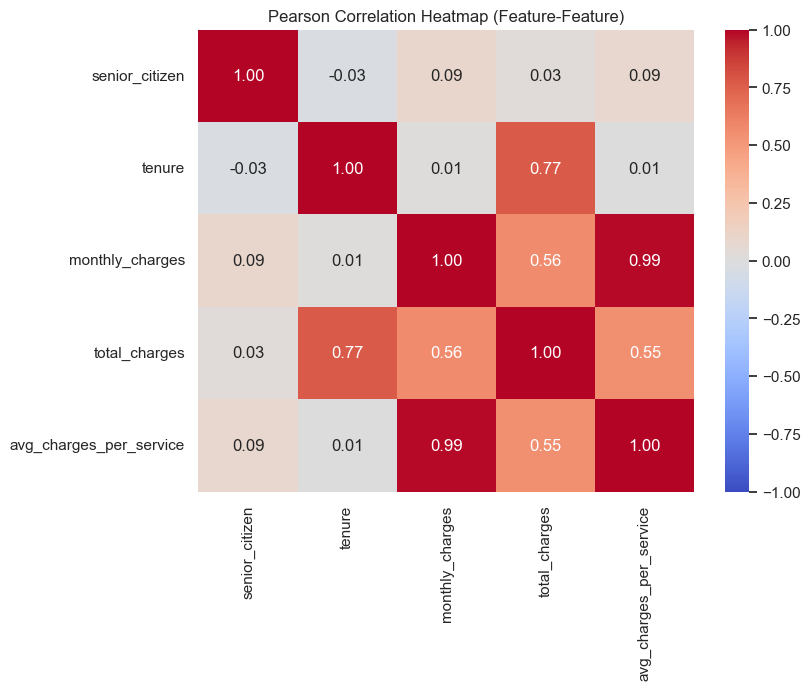

In [3]:
# Compute correlation matrix for independent features
features = ['senior_citizen', 'tenure', 'monthly_charges', 'total_charges', 'avg_charges_per_service']
corr_matrix = df[features].corr()

# Visualize as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Pearson Correlation Heatmap (Feature-Feature)")
plt.show()

In [4]:
# Filter out pairs with correlation > 0.9
threshold = 0.9
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column].abs() > threshold)]

print(f"Features identified as highly redundant (|r| > {threshold}): {to_drop}")
print("Action: We should drop these features to prevent multicollinearity and reduce model complexity.")

Features identified as highly redundant (|r| > 0.9): ['avg_charges_per_service']
Action: We should drop these features to prevent multicollinearity and reduce model complexity.


### 3. Feature-Target Correlation (Selection)
Now we calculate the correlation between the remaining features and the target variable (`churn_risk`). We keep features that exhibit a strong linear relationship.

In [5]:
# Drop the redundant features first
df_reduced = df.drop(columns=to_drop)

# Calculate correlation with the target
target_corr = df_reduced.corr()['churn_risk'].drop('churn_risk')

print("Correlation with Target (churn_risk):")
print(target_corr.sort_values(ascending=False))

# Apply threshold for selection (e.g., keep features with absolute correlation > 0.1)
target_threshold = 0.1
selected_features = target_corr[target_corr.abs() > target_threshold].index.tolist()

print(f"\nFeatures selected for modeling (|r| > {target_threshold}): {selected_features}")

Correlation with Target (churn_risk):
monthly_charges    0.423907
senior_citizen     0.315681
total_charges     -0.281338
tenure            -0.680394
Name: churn_risk, dtype: float64

Features selected for modeling (|r| > 0.1): ['senior_citizen', 'tenure', 'monthly_charges', 'total_charges']


### 4. Limitations: The Linearity Constraint
Pearson's correlation only captures *linear* relationships. A feature with a strong, predictable non-linear relationship will result in a near-zero Pearson score, causing us to incorrectly discard it if we rely on Pearson alone.

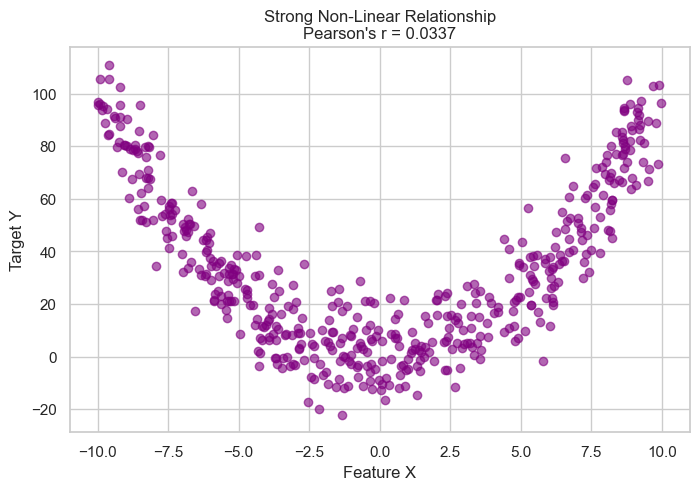

Observation: Despite X perfectly determining the overall shape of Y, Pearson's r is nearly 0. This is why Pearson is only a first-pass diagnostic!


In [6]:
# Generate a feature with a perfect quadratic (U-shaped) relationship to a target
X_nonlinear = np.random.uniform(-10, 10, 500)
Y_nonlinear = X_nonlinear**2 + np.random.normal(0, 10, 500)

# Calculate Pearson correlation
r_nonlinear = np.corrcoef(X_nonlinear, Y_nonlinear)[0, 1]

# Plot the relationship
plt.figure(figsize=(8, 5))
plt.scatter(X_nonlinear, Y_nonlinear, alpha=0.6, color='purple')
plt.title(f"Strong Non-Linear Relationship\nPearson's r = {r_nonlinear:.4f}")
plt.xlabel("Feature X")
plt.ylabel("Target Y")
plt.show()

print("Observation: Despite X perfectly determining the overall shape of Y, Pearson's r is nearly 0. " 
      "This is why Pearson is only a first-pass diagnostic!")